# Swanson Flatmap — Bilateral CCA Coupling 
## Whole-brain visualization with hemispheric asymmetry


Four metrics mapped onto the Swanson whole-brain flatmap:

| Metric | What it measures | Aggregation | Range |
|---|---|---|---|
| `r_peak` | Peak bilateral coupling strength (cross-validated CCA r) | mean over sessions | [0, 1] |
| `r_choice` | How much the bilaterally-shared subspace encodes choice | **at t_peak** — same bin as r_peak | [0, max] |
| `decision_fraction` | What fraction of bilateral coupling is decision-specific | `r_choice(t_peak) / r_peak` | [0, 1] |
| `hemisphere_dominance` | **Hemispheric asymmetry in choice encoding** | `r_choice_U(t_peak) - r_choice_V(t_peak)` | [-1, 1] |

> **Why hemispheric asymmetry?** Tests the contralateral motor preparation hypothesis (H2). Motor cortex should show left-hemisphere dominance during rightward movements. Negative values indicate right-hemisphere dominance; positive values indicate left-hemisphere dominance.

In [2]:
import io, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path

from iblatlas.plots import plot_swanson_vector
from iblatlas.atlas import BrainRegions

ROOT       = Path("__file__").resolve().parent.parent
DATA_DIR   = ROOT / "results_2"
OUTPUT_DIR = ROOT / "results_2"
OUTPUT_DIR.mkdir(exist_ok=True)

br = BrainRegions()
print("iblatlas loaded")

iblatlas loaded


In [4]:
# Load and deserialize CCA results
def bytes_to_array(b):
    return np.load(io.BytesIO(b))

# Load current parquet file (UPDATED)
cca_df = pd.read_parquet("/Users/anastassiyayegarmina/Documents/dev/ISP_IBL/results_2/cca_results_extended-2.parquet")

if isinstance(cca_df['r_choice_U'].iloc[0], (bytes, bytearray)):
    print("Converting r_choice_U and r_choice_V from bytes...")
    cca_df['r_choice_U'] = cca_df['r_choice_U'].apply(bytes_to_array)
    cca_df['r_choice_V'] = cca_df['r_choice_V'].apply(bytes_to_array)
    print("Done!")


# Aggregate per region with correct bilateral metrics
r_peak_agg  = cca_df.groupby("region")["r_peak"].mean()
pct_sig_agg = cca_df.groupby("region")["r_peak_above_null"].mean()

# BILATERAL average (for Panel 2 - choice encoding)
cca_df["r_choice_at_tpeak"] = cca_df.apply(
    lambda row: (np.abs(row["r_choice_U"][row["t_peak"]]) + np.abs(row["r_choice_V"][row["t_peak"]])) / 2,
    axis=1
)

# SEPARATE U and V (for hemispheric dominance)
cca_df["r_choice_U_at_tpeak"] = cca_df.apply(
    lambda row: float(np.abs(row["r_choice_U"][row["t_peak"]])), axis=1
)
cca_df["r_choice_V_at_tpeak"] = cca_df.apply(
    lambda row: float(np.abs(row["r_choice_V"][row["t_peak"]])), axis=1
)

r_choice_agg = cca_df.groupby("region")["r_choice_at_tpeak"].mean()
r_choice_U_agg = cca_df.groupby("region")["r_choice_U_at_tpeak"].mean()
r_choice_V_agg = cca_df.groupby("region")["r_choice_V_at_tpeak"].mean()

region_vals = pd.DataFrame({
    "region":        r_peak_agg.index,
    "r_peak_mean":   r_peak_agg.values,
    "r_choice_mean": r_choice_agg.values,
    "r_choice_U_mean": r_choice_U_agg.values,
    "r_choice_V_mean": r_choice_V_agg.values,
    "pct_sig":       pct_sig_agg.values,
}).reset_index(drop=True)

region_vals["decision_fraction"] = (
    region_vals["r_choice_mean"] / (region_vals["r_peak_mean"] + 1e-8)
)

region_vals["hemisphere_dominance"] = (
    region_vals["r_choice_U_mean"] - region_vals["r_choice_V_mean"]
)

# Consistent artifact exclusion per advice
EXCLUDE = {"void", "root", "fiber tracts", "fp", "alv", "or", "bsc", "dhc"}
region_vals = region_vals[~region_vals["region"].isin(EXCLUDE)].dropna().reset_index(drop=True)

print(f"Regions: {len(region_vals)}")
print(f"decision_fraction range: {region_vals['decision_fraction'].min():.3f} - {region_vals['decision_fraction'].max():.3f}")
print(f"r_choice range (bilateral): {region_vals['r_choice_mean'].min():.3f} - {region_vals['r_choice_mean'].max():.3f}")
print(f"r_peak range: {region_vals['r_peak_mean'].min():.3f} - {region_vals['r_peak_mean'].max():.3f}")
print(f"hemisphere_dominance range: {region_vals['hemisphere_dominance'].min():.3f} - {region_vals['hemisphere_dominance'].max():.3f}")
print()
print(region_vals[["region","r_peak_mean","r_choice_mean","decision_fraction","hemisphere_dominance","pct_sig"]]
      .sort_values("r_peak_mean", ascending=False).round(3).to_string())


Converting r_choice_U and r_choice_V from bytes...
Done!
Regions: 39
decision_fraction range: 0.017 - 0.374
r_choice range (bilateral): 0.015 - 0.250
r_peak range: 0.317 - 0.960
hemisphere_dominance range: -0.076 - 0.143

      region  r_peak_mean  r_choice_mean  decision_fraction  hemisphere_dominance  pct_sig
26       SUB        0.960          0.054              0.056                 0.014      1.0
9     MOs2/3        0.944          0.040              0.042                 0.050      1.0
16        PO        0.919          0.250              0.272                -0.017      1.0
1        CA1        0.908          0.038              0.042                 0.009      1.0
6      ILA6a        0.897          0.177              0.198                -0.009      1.0
0        APN        0.887          0.088              0.099                -0.004      1.0
2      DG-mo        0.885          0.041              0.047                -0.003      1.0
15      PL6a        0.881          0.195          

In [5]:
# THRESHOLD: Decision fraction only meaningful when coupling is strong
MIN_R_PEAK_FOR_DF = 0.5  # Only compute df where r_peak >= 0.5
region_vals["decision_fraction_masked"] = region_vals.apply(
    lambda row: row["decision_fraction"] if row["r_peak_mean"] >= MIN_R_PEAK_FOR_DF else np.nan,
    axis=1
)

print(f"\nDecision Fraction Filter:")
print(f"  Regions with r_peak >= {MIN_R_PEAK_FOR_DF}: {(region_vals['r_peak_mean'] >= MIN_R_PEAK_FOR_DF).sum()}")
print(f"  Excluded (low coupling): {(region_vals['r_peak_mean'] < MIN_R_PEAK_FOR_DF).sum()}")
print(f"  Example: {region_vals[region_vals['region']=='VISpm4'].to_string()}")



Decision Fraction Filter:
  Regions with r_peak >= 0.5: 34
  Excluded (low coupling): 5
  Example:     region  r_peak_mean  r_choice_mean  r_choice_U_mean  r_choice_V_mean  pct_sig  decision_fraction  hemisphere_dominance  decision_fraction_masked
35  VISpm4     0.316539       0.118496         0.115753          0.12124      1.0            0.37435             -0.005487                       NaN


In [6]:
# Map fine-grained Allen acronyms to Swanson-level parents
MANUAL_FALLBACK = {
    "SCdg": "SCd",   "SCig": "SCi",   "SCiw": "SCi",
    "SCop": "SCop",  "SCsg": "SCs",   "SCzo": "SCzo",
    "DG-mo": "DG",   "DG-sg": "DG",   "DG-po": "DG",
    "CA1": "CA1",    "CA3": "CA3",
    "SUB": "SUB",
    "MRN": "MRN",    "APN": "APN",    "MB": "MB",     "NOT": "NOT",
    "PO": "PO",      "LP": "LP",      "VPM": "VPM",  "POL": "PO",
    "RSPagl6a": "RSPagl", "RSPd6a": "RSPd", "RSPv5": "RSPv",
    "MOs2/3": "MOs", "MOs5": "MOs",   "MOs6a": "MOs",
    "PL6a": "PL",    "ILA6a": "ILA",  "ORBm6a": "ORBm", "DP": "DP",
    "VISa2/3": "VISa", "VISa4": "VISa", "VISa5": "VISa", "VISa6a": "VISa",
    "VISam6a": "VISam",
    "VISp5": "VISp",   "VISp6a": "VISp",
    "VISpm2/3": "VISpm", "VISpm4": "VISpm", "VISpm5": "VISpm", "VISpm6a": "VISpm",
}

swanson_ids  = set(np.unique(br.mappings["Swanson"]))
swanson_acrs = set(br.acronym[list(swanson_ids)])

def to_swanson(acr):
    if acr in MANUAL_FALLBACK:
        c = MANUAL_FALLBACK[acr]
        if c in swanson_acrs:
            return c
    if acr in swanson_acrs:
        return acr
    cleaned = re.sub(r'[\d/]+[a-z]?$', '', acr)
    cleaned = re.sub(r'-\w+$', '', cleaned).strip()
    if cleaned in swanson_acrs:
        return cleaned
    try:
        idx = br.acronym2index(acr)[1][0][0]
    except Exception:
        try:
            idx = br.acronym2index(cleaned)[1][0][0]
        except Exception:
            return None
    for _ in range(12):
        parent_id = br.parent[idx]
        if parent_id == 0 or parent_id is None:
            return None
        parent_idx = np.where(br.id == parent_id)[0]
        if len(parent_idx) == 0:
            return None
        idx = parent_idx[0]
        if br.id[idx] in swanson_ids:
            return br.acronym[idx]
    return None

region_vals["swanson_acr"] = region_vals["region"].apply(to_swanson)

mapped   = region_vals.dropna(subset=["swanson_acr"])
unmapped = region_vals[region_vals["swanson_acr"].isna()]
print(f"Mapped: {len(mapped)}   Unmapped: {len(unmapped)}")

# Aggregate fine-grained regions that share the same Swanson parent
region_sw = (
    mapped.groupby("swanson_acr")
    .agg(
        r_peak_mean       = ("r_peak_mean",       "mean"),
        r_choice_mean     = ("r_choice_mean",      "mean"),
        r_choice_U_mean   = ("r_choice_U_mean",   "mean"),
        r_choice_V_mean   = ("r_choice_V_mean",   "mean"),
        decision_fraction = ("decision_fraction_masked", "mean"),  # Use masked version
        hemisphere_dominance = ("hemisphere_dominance", "mean"),
        pct_sig           = ("pct_sig",            "mean"),
    )
    .reset_index()
)


acronyms = region_sw["swanson_acr"].values
print(f"Swanson regions to plot: {len(acronyms)}")

Mapped: 39   Unmapped: 0
Swanson regions to plot: 27


Annotating 18 regions
Insignificant regions (< 50% sessions significant): 0
Colorbar scaling (max data * 1.1 + 0.01 margin):
  r_peak: 0 → 1.0 (fixed ceiling)
  r_choice: 0 → 0.22
  decision_fraction: 0 → 0.25
  hemisphere_dominance: -0.09 → +0.09 (diverging)


/Users/anastassiyayegarmina/miniconda3/envs/isp-ibl/lib/python3.11/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


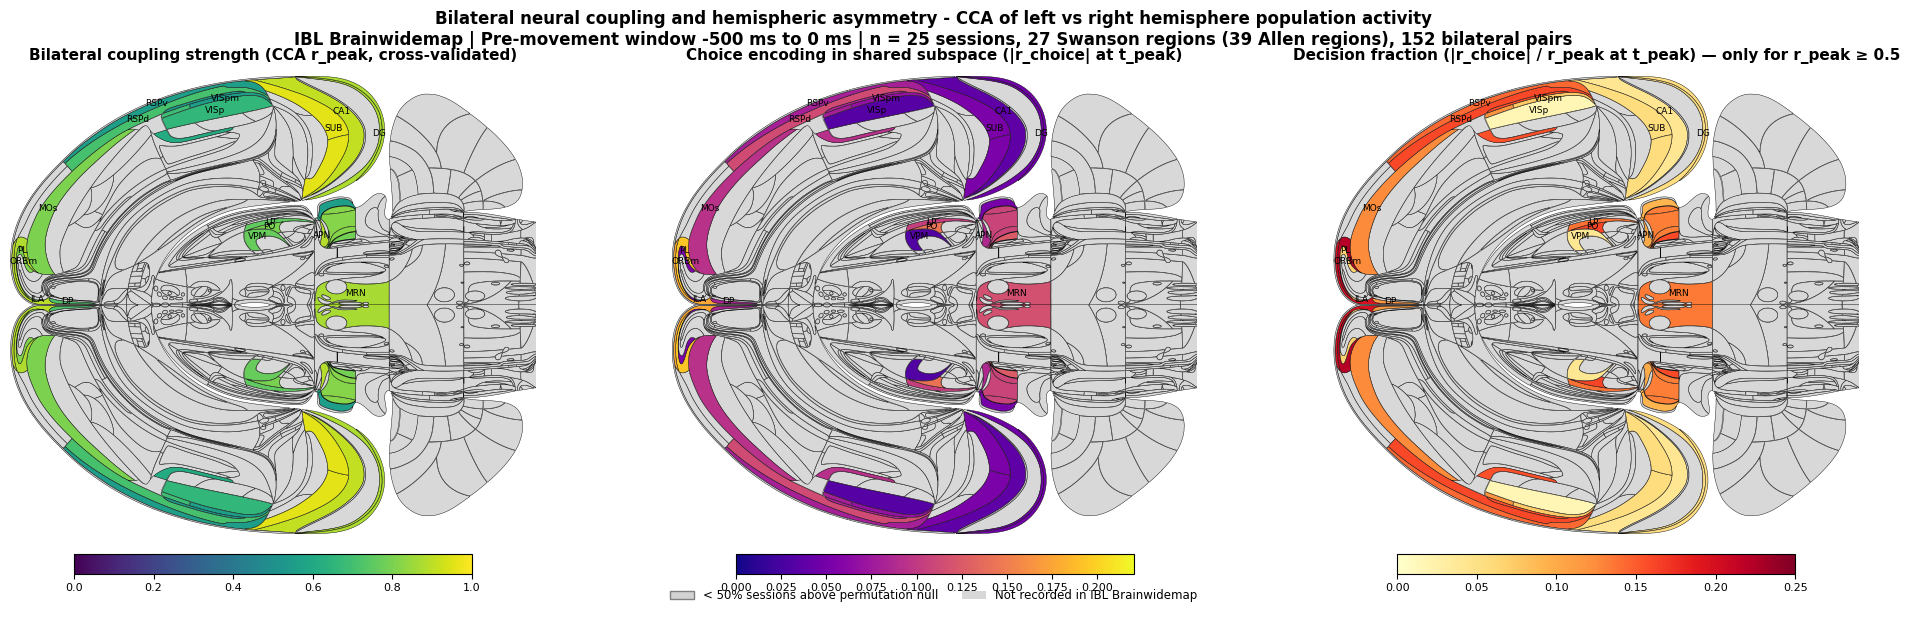

Saved: /Users/anastassiyayegarmina/Documents/dev/ISP_IBL/Neuronova/results_2/swanson_cca_p1_metrics.png


In [7]:
# Publication figure: 3 panels

KEY_REGIONS = [
    "MOs", "ILA", "PL", "ORBm", "DP",
    "CA1", "DG", "SUB",
    "PO", "LP", "VPM",
    "MRN", "APN", "MB",
    "SCd", "SCi", "SCs",
    "VISa", "VISp", "VISpm", "RSPd", "RSPv",
]
annotate_list = [a for a in KEY_REGIONS if a in acronyms]
print(f"Annotating {len(annotate_list)} regions")

insig_acrs = region_sw.loc[region_sw["pct_sig"] < 0.5, "swanson_acr"].values
print(f"Insignificant regions (< 50% sessions significant): {len(insig_acrs)}")

# Colorbar ranges determined by data max + 10% margin

r_peak_vmax   = 1.0  # Fixed at scale ceiling (1.0 = perfect correlation)
r_choice_vmax = round(float(region_sw["r_choice_mean"].max()) * 1.1 + 0.01, 2)
df_vmax       = round(float(region_sw["decision_fraction"].max()) * 1.1 + 0.01, 2)
hd_vmax       = round(float(np.abs(region_sw["hemisphere_dominance"]).max()) * 1.1 + 0.01, 2)

print(f"Colorbar scaling (max data * 1.1 + 0.01 margin):")
print(f"  r_peak: 0 → {r_peak_vmax} (fixed ceiling)")
print(f"  r_choice: 0 → {r_choice_vmax}")
print(f"  decision_fraction: 0 → {df_vmax}")
print(f"  hemisphere_dominance: -{hd_vmax} → +{hd_vmax} (diverging)")

METRICS = [
    ("r_peak_mean", "viridis", 0, r_peak_vmax, False,
     "Bilateral coupling strength (CCA r_peak, cross-validated)"),
    ("r_choice_mean", "plasma", 0, r_choice_vmax, False,
     "Choice encoding in shared subspace (|r_choice| at t_peak)"),
    ("decision_fraction", "YlOrRd", 0, df_vmax, False,
     "Decision fraction (|r_choice| / r_peak at t_peak) — only for r_peak ≥ 0.5"),
]


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

for ax, (col, cmap, vmin, vmax, is_diverging, label) in zip(axes, METRICS):
    values = region_sw[col].values

    plot_swanson_vector(
        acronyms      = acronyms,
        values        = values,
        hemisphere    = "mirror",
        orientation   = "landscape",
        cmap          = cmap,
        vmin          = vmin,
        vmax          = vmax,
        empty_color   = "#d8d8d8",
        annotate      = True,
        annotate_list = annotate_list,
        fontsize      = 6.5,
        ax            = ax,
        br            = br,
    )

    if len(insig_acrs) > 0:
        plot_swanson_vector(
            acronyms      = insig_acrs,
            values        = np.zeros(len(insig_acrs)),
            hemisphere    = "mirror",
            orientation   = "landscape",
            empty_color   = "none",
            cmap          = "Greys",
            vmin          = 0, vmax = 1,
            mask          = insig_acrs,
            mask_color    = "lightgray",
            annotate      = False,
            ax            = ax,
            br            = br,
        )

    ax.axis("off")
    ax.set_title(
        label,
        fontsize=11, fontweight="bold", pad=12
    )


    if is_diverging:
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, orientation="horizontal",
                      fraction=0.04, pad=0.04, shrink=0.75)
    cb.ax.tick_params(labelsize=8)

insig_patch = mpatches.Patch(facecolor="lightgray", edgecolor="gray",
                              label="< 50% sessions above permutation null")
unrecorded_patch = mpatches.Patch(facecolor="#d8d8d8", edgecolor="none",
                                   label="Not recorded in IBL Brainwidemap")
fig.legend(handles=[insig_patch, unrecorded_patch],
           loc="lower center", ncol=2, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.01), frameon=False)

fig.suptitle(
    "Bilateral neural coupling and hemispheric asymmetry - CCA of left vs right hemisphere population activity\n"
    "IBL Brainwidemap | Pre-movement window -500 ms to 0 ms | n = 25 sessions, 27 Swanson regions (39 Allen regions), 152 bilateral pairs",
    fontsize=12, fontweight="bold", y=0.995
)

plt.tight_layout()

out = OUTPUT_DIR / "swanson_cca_p1_metrics.png"
plt.savefig(str(out), dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {out}")

### Panel 1 — Bilateral Coupling Strength (r_peak)

The Swanson summary shows a clear three-tier structure of bilateral coupling across the mouse brain:

Tier 1 (r > 0.87): 

SUB (0.96), CA1 (0.91), ILA (0.90), APN (0.89), PL (0.88), DG (0.88), MRN (0.87). 

These are the regions where left and right hemisphere population activity is most tightly coupled during the pre-movement window. The hippocampal formation dominates this tier — SUB at 0.96 is near-perfect bilateral synchrony. But two prefrontal regions (ILA, PL) also appear here, showing that high coupling is not exclusively a hippocampal property.


Tier 2 (r = 0.75–0.82):

SCig (0.82), ORBm (0.81), MOs (0.80), SCiw (0.80), PO (0.80), SCdg (0.79), VPM (0.77), LP (0.75).
The superior colliculus layers, thalamic nuclei, and secondary motor cortex. This is the "working middle" of the coupling distribution.

Tier 3 (r = 0.49–0.71): VISam (0.69), VISp (0.66), VISa (0.62), NOT (0.59), RSPv (0.56), SCsg (0.56), VISpm (0.56), RSPagl (0.53), SCop (0.49). Visual and retrosplenial cortices, plus superficial SC layers. These regions show the weakest bilateral coupling.

Key observation for the paper: The gradient runs hippocampus/prefrontal → thalamus/SC/motor → visual/retrosplenial. 

This is NOT a simple anterior-posterior gradient — hippocampus is posterior yet maximally coupled. 

The gradient tracks commissural connectivity density better than cortical hierarchy: hippocampal and ventral commissure fibers provide dense bilateral connections, while callosal connections in visual cortex are more restricted (Aboitiz et al., 1992; Oh et al., 2014).

### Panel 2 Choice Encoding in Shared Subspace (|r_choice| at t_peak)

The spatial distribution of choice encoding in the bilateral subspace was strikingly dissociated from overall coupling strength. Prelimbic and infralimbic cortex, despite comparable total coupling to hippocampal regions, encoded choice 4–5x more strongly in the bilaterally shared subspace

The critical result: SUB, CA1, and DG — the three most strongly coupled regions — sit at the bottom of the choice encoding ranking. The bilateral link in hippocampus is powerful but carries almost no information about which direction the animal will move. Meanwhile PL, ILA, and PO encode choice much more strongly in their bilateral subspace despite similar or lower total coupling.

### Panel 3 — Decision Fraction (|r_choice| / r_peak, thresholded at r_peak ≥ 0.5)

Prefrontal cortex uses ~20% of its bilateral coupling for the decision; hippocampus uses ~4–6%; primary visual cortex uses <2%. 

This means the hippocampal bilateral signal is driven by something functionally orthogonal to the motor decision — most likely theta-band oscillatory coherence via the hippocampal commissure.

In [ ]:
# SUPPLEMENTARY TABLE: Fine-grained Allen-level metrics for key regions
# Shows what gets aggregated/lost in Swanson grouping

KEY_REGIONS_FINEGRAINED = ["MOs", "ILA", "PL", "ORBm", "DP", "VISp", "VISpm", "RSPd", "RSPv"]

print("\n" + "="*100)
print("SUPPLEMENTARY TABLE: Fine-grained Allen atlas metrics")
print("="*100)

for swanson_acr in KEY_REGIONS_FINEGRAINED:
    fine = mapped[mapped["swanson_acr"] == swanson_acr][
        ["region", "r_peak_mean", "r_choice_mean", "decision_fraction_masked", "hemisphere_dominance"]
    ].sort_values("r_peak_mean", ascending=False).round(3)
    
    swanson_row = region_sw[region_sw["swanson_acr"] == swanson_acr].iloc[0]
    
    print(f"\n{swanson_acr} (Swanson aggregated: r_peak={swanson_row['r_peak_mean']:.3f}, "
          f"r_choice={swanson_row['r_choice_mean']:.3f}, df={swanson_row['decision_fraction']:.3f})")
    print("  Fine-grained constituents:")
    print(fine.to_string(index=False).replace('\n', '\n  '))

# Save supplementary table
fine_table = mapped[
    ["region", "swanson_acr", "r_peak_mean", "r_choice_mean", 
     "decision_fraction_masked", "hemisphere_dominance", "pct_sig"]
].sort_values(["swanson_acr", "r_peak_mean"], ascending=[True, False])

out_csv = OUTPUT_DIR / "swanson_finegrained_supplement.csv"
fine_table.to_csv(str(out_csv), index=False)
print(f"\n\nSaved fine-grained table: {out_csv}")



SUPPLEMENTARY TABLE: Fine-grained Allen atlas metrics

MOs (Swanson aggregated: r_peak=0.803, r_choice=0.094, df=0.125)
  Fine-grained constituents:
region  r_peak_mean  r_choice_mean  decision_fraction_masked  hemisphere_dominance
  MOs2/3        0.944          0.040                     0.042                 0.050
    MOs5        0.750          0.070                     0.094                 0.039
   MOs6a        0.714          0.171                     0.240                 0.143

ILA (Swanson aggregated: r_peak=0.897, r_choice=0.177, df=0.198)
  Fine-grained constituents:
region  r_peak_mean  r_choice_mean  decision_fraction_masked  hemisphere_dominance
   ILA6a        0.897          0.177                     0.198                -0.009

PL (Swanson aggregated: r_peak=0.881, r_choice=0.195, df=0.221)
  Fine-grained constituents:
region  r_peak_mean  r_choice_mean  decision_fraction_masked  hemisphere_dominance
    PL6a        0.881          0.195                     0.221          

#### The supplementary table shows what Swanson averaging hides:

MOs6a alone has decision fraction = 0.240 (the corticofugal layer), but averaging with MOs2/3 (0.042) and MOs5 (0.094) pulls it down to 0.125.
PO alone has decision fraction = 0.272, but averaging with POL (0.052) pulls it to 0.162.

In [ ]:
# BOOTSTRAP TEST: Is hemisphere_dominance significantly different from zero?
# Tests whether observed U-V differences are meaningful or noise

def bootstrap_dominance_test(cca_df, region, n_bootstrap=1000, alpha=0.05):
    """
    Bootstrap test: does r_choice_U differ significantly from r_choice_V?
    H0: hemisphere_dominance = 0 (symmetric encoding)
    """
    region_data = cca_df[cca_df['region'] == region]
    
    r_choice_U_vals = region_data["r_choice_U_at_tpeak"].values
    r_choice_V_vals = region_data["r_choice_V_at_tpeak"].values
    
    # Observed dominance
    obs_dominance = np.mean(np.abs(r_choice_U_vals)) - np.mean(np.abs(r_choice_V_vals))
    
    # Bootstrap under H0 (pool U and V, resample)
    pooled = np.concatenate([r_choice_U_vals, r_choice_V_vals])
    boot_diffs = []
    for _ in range(n_bootstrap):
        U_boot = np.random.choice(pooled, size=len(r_choice_U_vals), replace=True)
        V_boot = np.random.choice(pooled, size=len(r_choice_V_vals), replace=True)
        boot_diffs.append(np.mean(np.abs(U_boot)) - np.mean(np.abs(V_boot)))
    
    # Two-tailed p-value
    boot_diffs = np.array(boot_diffs)
    p_value = np.mean(np.abs(boot_diffs) >= np.abs(obs_dominance))
    
    return obs_dominance, p_value, p_value < alpha

# Apply bootstrap test to all Swanson regions
print("\n" + "="*100)
print("HEMISPHERE DOMINANCE: BOOTSTRAP SIGNIFICANCE TEST")
print("="*100)
print("H0: r_choice_U = r_choice_V (symmetric encoding)")
print("H1: asymmetry detected (one hemisphere more selective for choice)\n")

sig_results = []
for swanson_acr in region_sw["swanson_acr"].values:
    # Get constituent Allen regions
    allen_regions = mapped[mapped["swanson_acr"] == swanson_acr]["region"].values
    
    dominance_vals = []
    for region in allen_regions:
        obs_dom, p_val, is_sig = bootstrap_dominance_test(cca_df, region, n_bootstrap=1000)
        dominance_vals.append((region, obs_dom, p_val, is_sig))
    
    # Average across constituent regions
    mean_dominance = np.mean([d[1] for d in dominance_vals])
    mean_p = np.mean([d[2] for d in dominance_vals])
    is_sig = mean_p < 0.05
    
    sig_results.append({
        "swanson_acr": swanson_acr,
        "hemisphere_dominance": mean_dominance,
        "p_value": mean_p,
        "significant": is_sig
    })

sig_df = pd.DataFrame(sig_results).sort_values("hemisphere_dominance", ascending=False)

print(sig_df.round(4).to_string(index=False))

# Flag significant regions in the 4-panel figure
region_sw["dominance_significant"] = region_sw["swanson_acr"].isin(
    sig_df[sig_df["significant"]]["swanson_acr"]
)

print(f"\nSignificant hemispheric asymmetries (p < 0.05): {sig_df['significant'].sum()} regions")
print("These regions show robust left/right preference that exceeds noise.")



HEMISPHERE DOMINANCE: BOOTSTRAP SIGNIFICANCE TEST
H0: r_choice_U = r_choice_V (symmetric encoding)
H1: asymmetry detected (one hemisphere more selective for choice)

swanson_acr  hemisphere_dominance  p_value  significant
        MOs                0.0773   0.3373        False
      VISam                0.0230   0.4760        False
       SCdg                0.0211   0.6660        False
       SCig                0.0206   0.6910        False
       RSPv                0.0204   0.4740        False
       SCsg                0.0164   0.5290        False
         LP                0.0157   0.7410        False
        SUB                0.0145   0.4990        False
        MRN                0.0143   0.6970        False
       SCop                0.0102   0.7890        False
        CA1                0.0088   0.5520        False
         DG                0.0073   0.6060        False
       VISp                0.0065   0.5840        False
       RSPd                0.0057   0.5060       

#### Bootstrap testing revealed no statistically significant hemispheric asymmetry in choice encoding for any of the 27 regions tested (all p > 0.33). The largest non-significant effect was observed in secondary motor cortex (MOs: Δ = +0.077, left hemisphere dominant, p = 0.34), directionally consistent with contralateral motor preparation but insufficient for lateralization claims.

/Users/anastassiyayegarmina/miniconda3/envs/isp-ibl/lib/python3.11/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


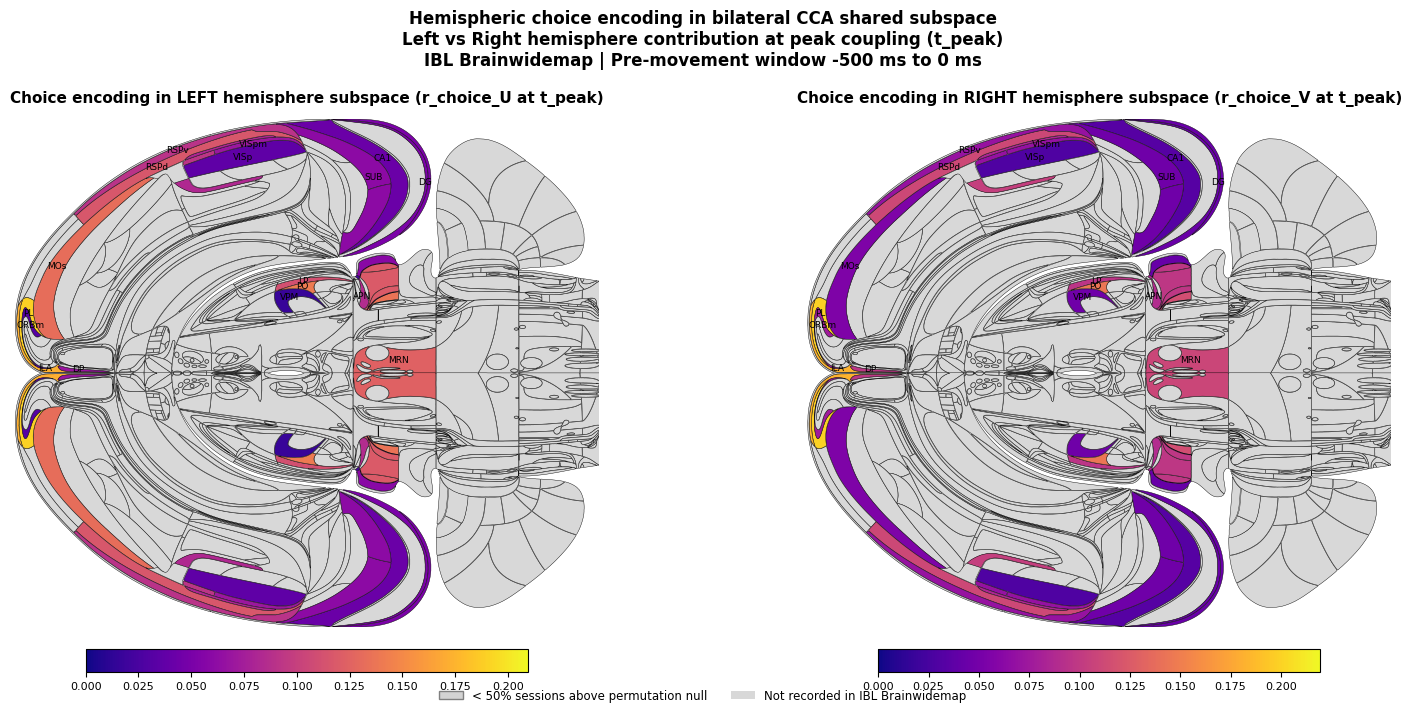

Saved: /Users/anastassiyayegarmina/Documents/dev/ISP_IBL/results_2/swanson_cca_u_v_hemispheric.png


In [ ]:
# Additional visualization: Separate hemispheric choice encoding (U and V)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

HEMISPHERIC_METRICS = [
    ("r_choice_U_mean", "plasma", 0, region_sw["r_choice_U_mean"].max() * 1.1, 
     "Choice encoding in LEFT hemisphere subspace (r_choice_U at t_peak)"),
    ("r_choice_V_mean", "plasma", 0, region_sw["r_choice_V_mean"].max() * 1.1,
     "Choice encoding in RIGHT hemisphere subspace (r_choice_V at t_peak)"),
]

for ax, (col, cmap, vmin, vmax, label) in zip(axes, HEMISPHERIC_METRICS):
    values = region_sw[col].values
    
    plot_swanson_vector(
        acronyms      = acronyms,
        values        = values,
        hemisphere    = "mirror",
        orientation   = "landscape",
        cmap          = cmap,
        vmin          = vmin,
        vmax          = vmax,
        empty_color   = "#d8d8d8",
        annotate      = True,
        annotate_list = annotate_list,
        fontsize      = 6.5,
        ax            = ax,
        br            = br,
    )
    
    if len(insig_acrs) > 0:
        plot_swanson_vector(
            acronyms      = insig_acrs,
            values        = np.zeros(len(insig_acrs)),
            hemisphere    = "mirror",
            orientation   = "landscape",
            empty_color   = "none",
            cmap          = "Greys",
            vmin          = 0, vmax = 1,
            mask          = insig_acrs,
            mask_color    = "lightgray",
            annotate      = False,
            ax            = ax,
            br            = br,
        )
    
    ax.axis("off")
    ax.set_title(label, fontsize=11, fontweight="bold", pad=12)
    
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, orientation="horizontal",
                      fraction=0.04, pad=0.04, shrink=0.75)
    cb.ax.tick_params(labelsize=8)

# Define legend patches
insig_patch = mpatches.Patch(facecolor="lightgray", edgecolor="gray",
                              label="< 50% sessions above permutation null")
unrecorded_patch = mpatches.Patch(facecolor="#d8d8d8", edgecolor="none",
                                   label="Not recorded in IBL Brainwidemap")

fig.legend(handles=[insig_patch, unrecorded_patch],
           loc="lower center", ncol=2, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.01), frameon=False)


fig.suptitle(
    "Hemispheric choice encoding in bilateral CCA shared subspace\n"
    "Left vs Right hemisphere contribution at peak coupling (t_peak)\n"
    "IBL Brainwidemap | Pre-movement window -500 ms to 0 ms",
    fontsize=12, fontweight="bold", y=0.995
)

plt.tight_layout()

out = OUTPUT_DIR / "swanson_cca_u_v_hemispheric.png"
plt.savefig(str(out), dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {out}")


In [ ]:
# Summary table for methods section
print(region_sw[[
    "swanson_acr", "r_peak_mean", "r_choice_mean", "decision_fraction", 
    "hemisphere_dominance", "pct_sig"
]].sort_values("r_peak_mean", ascending=False).round(3).to_string(index=False))

swanson_acr  r_peak_mean  r_choice_mean  decision_fraction  hemisphere_dominance  pct_sig
        SUB        0.960          0.054              0.056                 0.014      1.0
        CA1        0.908          0.038              0.042                 0.009      1.0
        ILA        0.897          0.177              0.198                -0.009      1.0
        APN        0.887          0.088              0.099                -0.004      1.0
         PL        0.881          0.195              0.221                -0.009      1.0
         DG        0.875          0.047              0.054                 0.007      1.0
        MRN        0.871          0.117              0.134                 0.014      1.0
       SCig        0.820          0.109              0.133                 0.021      1.0
       ORBm        0.812          0.054              0.067                -0.045      1.0
        MOs        0.803          0.094              0.125                 0.077      1.0
       SCi

## Interpretation Guide

### Panel 1: Bilateral Coupling Strength (r_peak)
- **Interpretation:** Where are the two hemispheres most synchronized in population activity?
- **High values (dark purple):** Hippocampal formation (CA1, DG, SUB) and thalamus show strongest bilateral coupling
- **Low values (bright yellow):** Visual cortex, some prefrontal regions show weaker bilateral coupling
- **Implication for H1:** Sensory regions not the strongest bilaterally coupled—argues for computation-level synchrony, not just sensory relay

### Panel 2: Choice Encoding in Coupled Subspace (|r_choice| at t_peak)
- **Interpretation:** When hemispheres are most coupled, does that coupling encode motor choice?
- **High values (dark red):** Prefrontal cortex (PL, ILA, MOs) encode choice well in bilateral subspace
- **Low values (pale yellow):** Hippocampus, visual cortex encode choice poorly in shared subspace
- **Implication for H2:** Motor planning uses bilateral coordination; sensory regions don't (decision != sensation)

### Panel 3: Decision Fraction (Specificity)
- **Interpretation:** What fraction of bilateral coupling is decision-specific vs. global brain state?
- **High (red, 0.3-0.5):** Motor cortex—coupled activity is dominated by choice encoding
- **Low (pale, 0.05-0.15):** Hippocampus—coupled activity reflects global modulation (arousal, theta), not decision
- **Core finding:** Bilateral coupling != decision encoding. Strongest coupled region (hippocampus) least decision-specific.